In [4]:
import os, sys
sidm_path = str(os.getcwd()).split('/sidm')[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)
from sidm.tools import utilities #scaleout, sidm_processor, llpnanoaodschema
from sidm.studies.cosmicVeto import functions
import matplotlib.pyplot as plt
utilities.set_plot_style()


In [5]:

data = functions.get_data_files()   


channels = [
   "cr_1egmOr1mu_lj_withoutEta_phi",
   "cr_1egmOr1mu_lj_withoutEta_phi_cosmic_veto", 
]


sum_data = {}
for channel_name in channels:
    folder_name = f"OutputFiles/{channel_name}"
    sum_data_all= utilities.sum_hist(data, folder_name)
    sum_data[channel_name] = sum_data_all
    



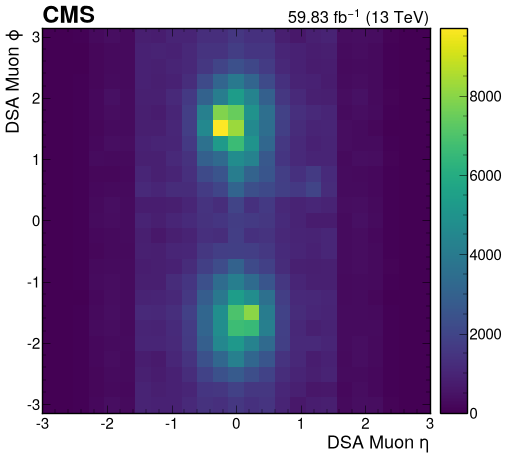

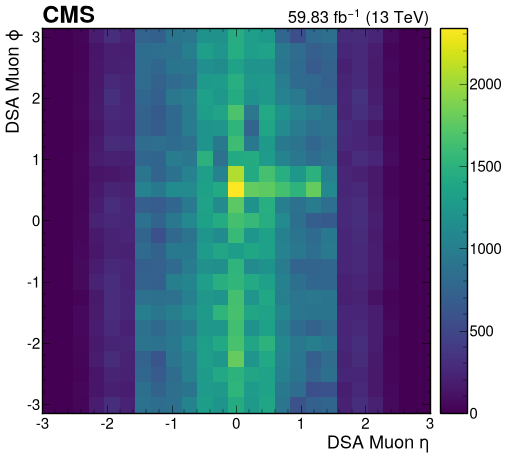

In [6]:
from matplotlib.colors import LogNorm,Normalize
import mplhep as hep
histogram_name = "dsaMuon_eta_phi"
for channel_name in channels:
    plt.figure()
    histogram = sum_data[channel_name][histogram_name][channel_name,::2j, ::2j]
    utilities.plot(histogram, flow = "none",skip_label=True)
    hep.cms.label(data=True, lumi=59.83,)

    plt.savefig(f"Plots/{channel_name}_{histogram_name}.png")
